# Level 2 - Task 1

## Restaurant Ratings Analysis

In [26]:
df['Aggregate rating'].describe()

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

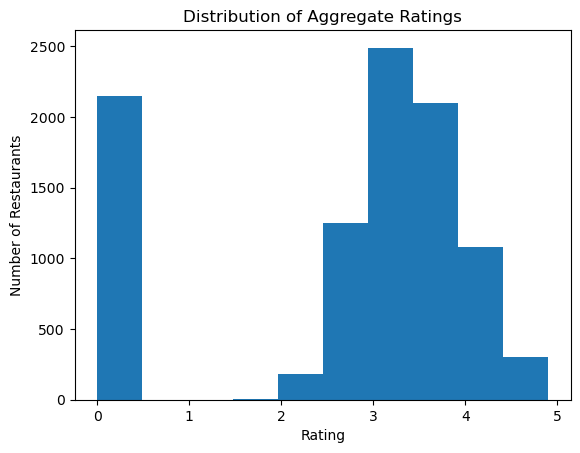

In [27]:
import matplotlib.pyplot as plt

plt.hist(df['Aggregate rating'], bins=10)

plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')

plt.show()

In [28]:
df['Aggregate rating'].value_counts().head(10)

Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     498
3.3     483
3.5     480
3.0     468
3.6     458
3.7     427
3.8     400
Name: count, dtype: int64

In [29]:
rating_ranges = pd.cut(
    df['Aggregate rating'],
    bins=[0,1,2,3,4,5]
)

rating_ranges.value_counts()

Aggregate rating
(3, 4]    4388
(2, 3]    1891
(4, 5]    1114
(1, 2]      10
(0, 1]       0
Name: count, dtype: int64

In [30]:
rating_ranges.value_counts().idxmax()

Interval(3, 4, closed='right')

In [31]:
df['Votes'].mean()

np.float64(156.909747670401)

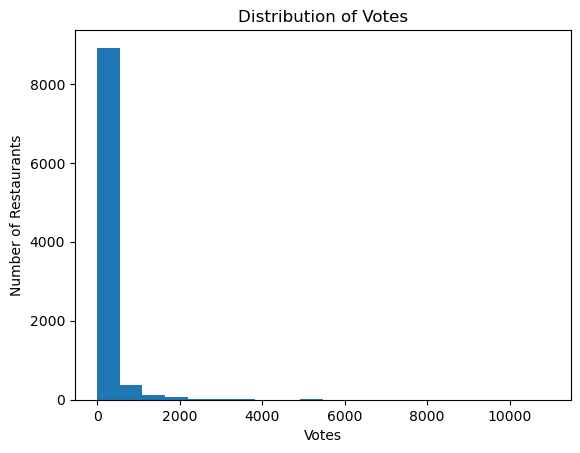

In [32]:
plt.hist(df['Votes'], bins=20)

plt.title('Distribution of Votes')
plt.xlabel('Votes')
plt.ylabel('Number of Restaurants')

plt.show()

# Level 2 - Task 1

## Restaurant Ratings Analysis

### Insights

1. Most restaurants have ratings between 3 and 4.
2. Very few restaurants have ratings below 2.
3. Highly rated restaurants (4–5) represent a smaller portion of the dataset.
4. The average number of votes received per restaurant is approximately 157.
5. Restaurants with more customer engagement tend to accumulate more votes.

## Task 2 - Cuisine Combination Analysis

In [33]:
df[['Restaurant Name', 'Cuisines']].head()

,Restaurant Name,Cuisines
0,Le Petit Souffle,"French, Japanese, Desserts"
1,Izakaya Kikufuji,Japanese
2,Heat - Edsa Shangri-La,"Seafood, Asian, Filipino, Indian"
3,Ooma,"Japanese, Sushi"
4,Sambo Kojin,"Japanese, Korean"


In [34]:
cuisine_combinations = df['Cuisines'].value_counts()

cuisine_combinations.head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [35]:
cuisine_combinations.head(10)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

In [36]:
combo_rating = df.groupby('Cuisines')['Aggregate rating'].mean()

combo_rating.sort_values(ascending=False).head(10)

Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64

In [37]:
combo_rating.sort_values(ascending=False).head(20)

Cuisines
Burger, Bar Food, Steak            4.90
American, Burger, Grill            4.90
American, Caribbean, Seafood       4.90
American, Coffee and Tea           4.90
Mexican, American, Healthy Food    4.90
Italian, Bakery, Continental       4.90
BBQ, Breakfast, Southern           4.90
European, German                   4.90
Hawaiian, Seafood                  4.90
Sunda, Indonesian                  4.90
American, BBQ, Sandwich            4.90
World Cuisine                      4.90
Continental, Indian                4.90
American, Sandwich, Tea            4.90
Mughlai, Lucknowi                  4.90
European, Contemporary             4.90
European, Asian, Indian            4.90
Italian, Deli                      4.90
Filipino, Mexican                  4.85
Beverages, International           4.80
Name: Aggregate rating, dtype: float64

In [38]:
combo_count = df['Cuisines'].value_counts()

combo_count.head(20)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
South Indian                      112
Bakery, Fast Food                 108
Chinese, North Indian             105
Mughlai                           103
Ice Cream, Desserts                83
Ice Cream                          74
North Indian, Fast Food            74
Name: count, dtype: int64

In [39]:
top_combos = combo_count[combo_count >= 20]

top_combos.head(20)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
South Indian                      112
Bakery, Fast Food                 108
Chinese, North Indian             105
Mughlai                           103
Ice Cream, Desserts                83
Ice Cream                          74
North Indian, Fast Food            74
Name: count, dtype: int64

In [40]:
popular_combo_ratings = df.groupby('Cuisines')['Aggregate rating'].mean()

popular_combo_ratings[top_combos.index].sort_values(ascending=False).head(10)

Cuisines
American                       3.667742
Italian                        3.657407
Italian, Pizza                 3.637500
Mexican                        3.636111
Continental                    3.566667
Fast Food, Burger              3.403571
Cafe, Tea                      3.375000
Bakery, Desserts, Fast Food    3.366667
American, Fast Food            3.350000
Chinese, Thai                  3.309804
Name: Aggregate rating, dtype: float64

# Level 2 - Task 2

## Cuisine Combination Analysis

### Insights

1. North Indian cuisine appears in many of the most common cuisine combinations.
2. "North Indian, Chinese" is the most popular multi-cuisine combination.
3. Several cuisine combinations achieved very high average ratings (4.8–4.9).
4. Multi-cuisine restaurants are common and offer customers a wider variety of food choices.
5. Cuisine combinations can influence customer ratings and restaurant popularity.

## Task 3 - Geographic Analysis

In [41]:
df[['Latitude','Longitude']].head()

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


In [42]:
df[['Latitude','Longitude']].isnull().sum()

Latitude     0
Longitude    0
dtype: int64

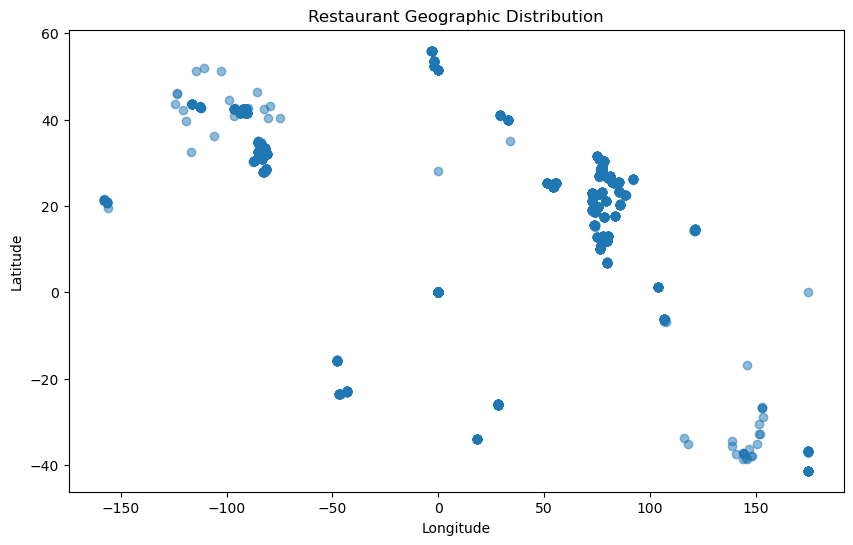

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.5
)

plt.title('Restaurant Geographic Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

In [44]:
top_cities = df['City'].value_counts().head(5).index

df_top = df[df['City'].isin(top_cities)]

df_top['City'].value_counts()

City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25
Name: count, dtype: int64

# Level 2 - Task 3

## Geographic Analysis

### Insights

1. Restaurant locations are not evenly distributed across all regions.
2. Certain cities contain a much higher concentration of restaurants.
3. Geographic clustering suggests strong restaurant activity in major urban areas.
4. Dense clusters indicate regions with high customer demand and business opportunities.
5. Location plays an important role in restaurant presence and visibility.

## Task 4 - Restaurant Chains Analysis

In [45]:
chain_counts = df['Restaurant Name'].value_counts()

chain_counts.head(20)

Restaurant Name
Cafe Coffee Day        83
Domino's Pizza         79
Subway                 63
Green Chick Chop       51
McDonald's             48
Keventers              34
Pizza Hut              30
Giani                  29
Baskin Robbins         28
Barbeque Nation        26
Dunkin' Donuts         22
Barista                22
Giani's                22
Pind Balluchi          20
Costa Coffee           20
Wah Ji Wah             19
Pizza Hut Delivery     19
Sagar Ratna            19
Twenty Four Seven      19
Republic of Chicken    18
Name: count, dtype: int64

In [46]:
chains = chain_counts[chain_counts > 1]

chains.head(20)

Restaurant Name
Cafe Coffee Day        83
Domino's Pizza         79
Subway                 63
Green Chick Chop       51
McDonald's             48
Keventers              34
Pizza Hut              30
Giani                  29
Baskin Robbins         28
Barbeque Nation        26
Dunkin' Donuts         22
Barista                22
Giani's                22
Pind Balluchi          20
Costa Coffee           20
Wah Ji Wah             19
Pizza Hut Delivery     19
Sagar Ratna            19
Twenty Four Seven      19
Republic of Chicken    18
Name: count, dtype: int64

In [47]:
chains.sort_values(ascending=False).head(10)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

In [48]:
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean()

chain_ratings.loc[chains.index].sort_values(ascending=False).head(10)

Restaurant Name
Talaga Sampireun             4.900
Silantro Fil-Mex             4.850
AB's Absolute Barbecues      4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Gymkhana                     4.700
The Cheesecake Factory       4.650
Dishoom                      4.600
Garota de Ipanema            4.600
Chili's                      4.580
Name: Aggregate rating, dtype: float64

In [49]:
chain_votes = df.groupby('Restaurant Name')['Votes'].mean()

chain_votes.loc[chains.index].sort_values(ascending=False).head(10)

Restaurant Name
Truffles                     4841.000000
Joey's Pizza                 3903.500000
AB's - Absolute Barbecues    3350.000000
Big Chill                    2713.250000
Big Yellow Door              2503.666667
Out Of The Box               2450.000000
Saravana Bhavan              2412.666667
Olive Bistro                 1854.000000
Talaga Sampireun             1838.000000
SpiceKlub                    1825.500000
Name: Votes, dtype: float64

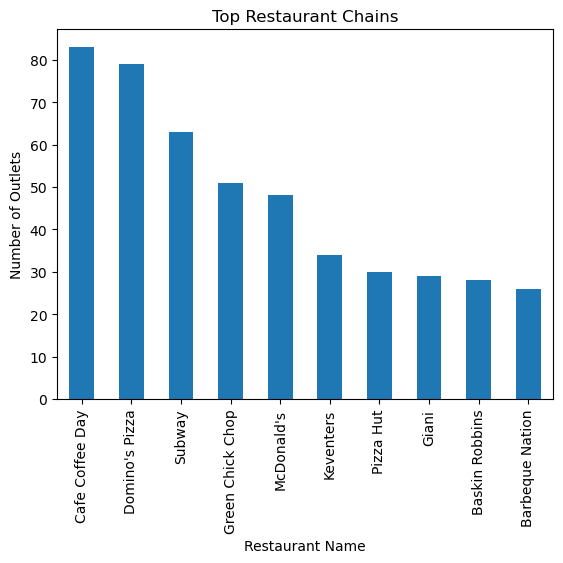

In [50]:
chains.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title('Top Restaurant Chains')
plt.xlabel('Restaurant Name')
plt.ylabel('Number of Outlets')

plt.show()

# Level 2 - Task 4

## Restaurant Chains Analysis

### Insights

1. Cafe Coffee Day is the largest restaurant chain in the dataset with 83 outlets.
2. Domino's Pizza and Subway also have a strong presence across multiple locations.
3. International fast-food brands such as McDonald's, Subway, and Pizza Hut appear prominently.
4. Coffee and quick-service restaurant chains dominate the restaurant landscape.
5. Strong brand recognition helps chains expand across multiple cities and attract customers.

In [51]:
chains.sort_values(ascending=False).head(10)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

# Project Conclusion

### Key Findings

1. North Indian cuisine is the most common cuisine in the dataset.
2. Restaurant distribution is concentrated in a few major cities.
3. Most restaurants belong to lower and medium price categories.
4. Restaurants offering online delivery tend to attract more customers.
5. Most restaurant ratings fall between 3 and 4.
6. North Indian and Chinese cuisine combinations are highly popular.
7. Restaurant activity is concentrated in urban locations.
8. Cafe Coffee Day is the largest restaurant chain in the dataset.

### Conclusion

The analysis provides valuable insights into restaurant trends, customer preferences, pricing patterns, delivery services, ratings, and restaurant chains. These insights can help businesses make data-driven decisions regarding expansion, marketing, and customer engagement.